# Monte Carlo Basket Options on Correlated Assets

## 1. What is a Basket Option?

A **basket option** is a derivative whose payoff depends on the weighted average of multiple underlying assets:

$$S_{\text{basket}}(T) = \sum_{i=1}^{n} w_i \, S_i(T)$$

where $w_i$ are the basket weights (usually $\sum w_i = 1$).

Common payoff types:
- **Call:** $\max(S_{\text{basket}}(T) - K, 0)$
- **Put:** $\max(K - S_{\text{basket}}(T), 0)$

Basket options are cheaper than a portfolio of individual options because the **averaging reduces volatility** (diversification benefit), and they are popular for hedging multi-asset exposure.

---

## 2. Multi-Asset Geometric Brownian Motion

Each asset follows GBM under the risk-neutral measure $\mathbb{Q}$:

$$dS_i(t) = r\,S_i(t)\,dt + \sigma_i\,S_i(t)\,dW_i^{\mathbb{Q}}(t)$$

The Brownian motions are **correlated**:

$$\mathbb{E}\left[dW_i(t)\,dW_j(t)\right] = \rho_{ij}\,dt$$

In matrix form, let $\mathbf{S}_t \in \mathbb{R}^n$ and $\mathbf{W}_t$ be a vector of correlated Brownian motions with covariance matrix $\Sigma$ where $\Sigma_{ij} = \rho_{ij}$.

---

## 3. Generating Correlated Paths: Cholesky Decomposition

To simulate correlated Brownian increments, we:
1. Generate $n$ independent standard normals $\mathbf{Z} \sim \mathcal{N}(0, I_n)$
2. Compute $\mathbf{L}$ such that $\Sigma = \mathbf{L}\mathbf{L}^\top$ (Cholesky)
3. Transform: $\mathbf{X} = \mathbf{L}\mathbf{Z} \sim \mathcal{N}(0, \Sigma)$

The Euler-Maruyama discretization for each asset:

$$S_i(t+\Delta t) = S_i(t)\,\exp\left[\left(r - \frac{\sigma_i^2}{2}\right)\Delta t + \sigma_i\sqrt{\Delta t}\,X_i\right]$$

This is exact for GBM (Milstein correction not needed).

---

## 4. Geometric Basket Closed-Form Benchmark

For a **geometric basket** (payoff on $\prod S_i^{w_i}$), there exists a closed-form formula analogous to Black-Scholes. We use it as a sanity check on our Monte Carlo engine.

The geometric basket can be viewed as a single asset with:
- Effective volatility: $\sigma_G^2 = \sum_i \sum_j w_i w_j \sigma_i \sigma_j \rho_{ij}$
- Effective dividend: $q_G = \frac{1}{2}\left(\sum_i w_i \sigma_i^2 - \sigma_G^2\right)$

Then the Black-Scholes formula applies to $S_G(0) = \prod_i S_i(0)^{w_i}$.

Below, we implement everything: simulation, pricing, convergence analysis, and visualizations.


In [2]:
# =============================================================================
# Imports & Setup
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import norm

# Matplotlib settings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# Reproducibility
np.random.seed(2026)


def safe_trapezoid(y, x):
    """Safe trapezoid integration (NumPy 2.0 compatible)."""
    try:
        return np.trapezoid(y, x)
    except AttributeError:
        return np.sum((y[:-1] + y[1:]) * np.diff(x) / 2.0)


# =============================================================================
# Market & Contract Parameters
# =============================================================================
r = 0.05          # Risk-free rate
T = 1.0           # Time to maturity (years)
K = 100.0         # Strike

# Three assets
n_assets = 3
S0 = np.array([100.0, 105.0, 95.0])      # Spot prices
sigma = np.array([0.20, 0.25, 0.30])     # Volatilities
weights = np.array([0.4, 0.35, 0.25])    # Basket weights (sum to 1)

# Correlation matrix (must be positive semi-definite)
corr = np.array([
    [1.00, 0.60, 0.30],
    [0.60, 1.00, 0.50],
    [0.30, 0.50, 1.00]
])

print("Basket weights sum:", f"{weights.sum():.4f}")
print("Correlation matrix eigenvalues:", np.linalg.eigvalsh(corr))


Basket weights sum: 1.0000
Correlation matrix eigenvalues: [0.3493407  0.70687847 1.94378083]


## 5. Visualizing the Correlation Structure

Before simulating, let's inspect the correlation matrix and its Cholesky factor. The Cholesky matrix $\mathbf{L}$ is lower-triangular and shows how each asset's random shock depends on the independent factors.


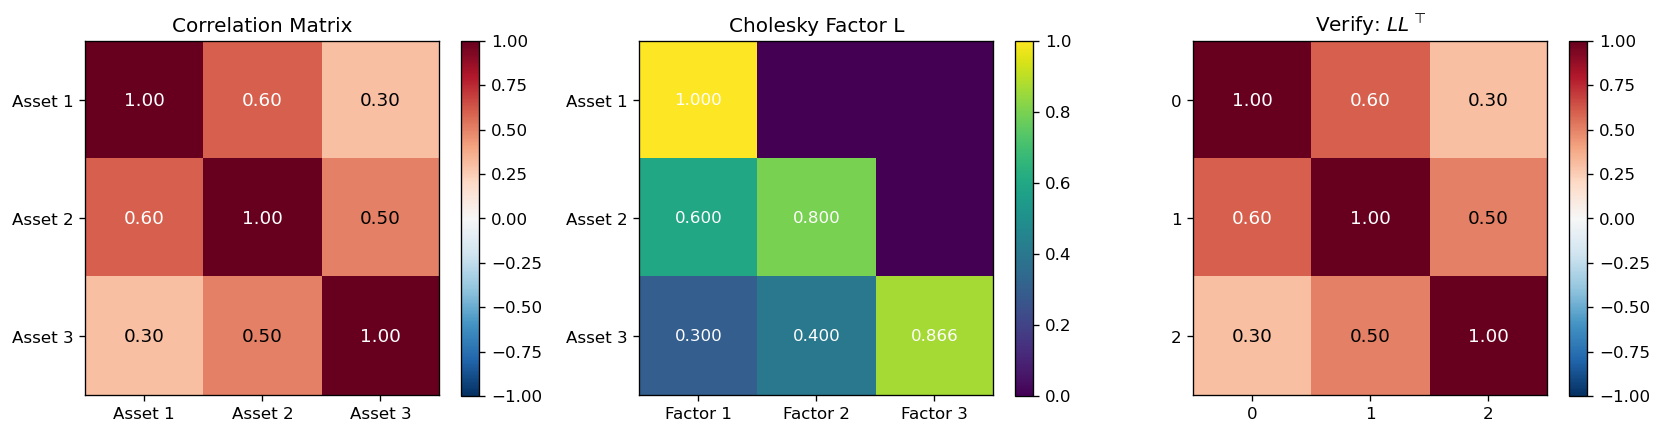

In [3]:
# =============================================================================
# Cholesky Decomposition & Correlation Visualization
# =============================================================================
L = np.linalg.cholesky(corr)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Correlation matrix heatmap
im1 = axes[0].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(n_assets))
axes[0].set_yticks(range(n_assets))
axes[0].set_xticklabels([f'Asset {i+1}' for i in range(n_assets)])
axes[0].set_yticklabels([f'Asset {i+1}' for i in range(n_assets)])
for i in range(n_assets):
    for j in range(n_assets):
        axes[0].text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', 
                     color='white' if abs(corr[i, j]) > 0.5 else 'black', fontsize=11)
axes[0].set_title('Correlation Matrix')
fig.colorbar(im1, ax=axes[0], shrink=0.8)

# Cholesky factor heatmap
im2 = axes[1].imshow(L, cmap='viridis')
axes[1].set_xticks(range(n_assets))
axes[1].set_yticks(range(n_assets))
axes[1].set_xticklabels([f'Factor {i+1}' for i in range(n_assets)])
axes[1].set_yticklabels([f'Asset {i+1}' for i in range(n_assets)])
for i in range(n_assets):
    for j in range(n_assets):
        if j <= i:
            axes[1].text(j, i, f'{L[i, j]:.3f}', ha='center', va='center', 
                         color='white', fontsize=10)
axes[1].set_title('Cholesky Factor L')
fig.colorbar(im2, ax=axes[1], shrink=0.8)

# Verify L @ L.T
reconstructed = L @ L.T
im3 = axes[2].imshow(reconstructed, cmap='RdBu_r', vmin=-1, vmax=1)
axes[2].set_xticks(range(n_assets))
axes[2].set_yticks(range(n_assets))
axes[2].set_title(r'Verify: $L L^{\top}$')
for i in range(n_assets):
    for j in range(n_assets):
        axes[2].text(j, i, f'{reconstructed[i, j]:.2f}', ha='center', va='center',
                     color='white' if abs(reconstructed[i, j]) > 0.5 else 'black', fontsize=11)
fig.colorbar(im3, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()


## 6. Monte Carlo Simulation Engine

We simulate $N$ paths for all $n$ assets simultaneously using vectorized NumPy operations. Each path uses the Cholesky-transformed correlated shocks.

The arithmetic basket price at maturity is:

$$A(T) = \sum_{i=1}^{n} w_i \, S_i(T)$$

The Monte Carlo estimate of a call option price is:

$$\hat{C} = e^{-rT} \cdot \frac{1}{N}\sum_{k=1}^{N} \max(A^{(k)}(T) - K, 0)$$

with standard error:

$$\text{SE} = \frac{e^{-rT} \cdot \text{std}(\text{payoffs})}{\sqrt{N}}$$


In [4]:
# =============================================================================
# Monte Carlo Simulation Function
# =============================================================================
def simulate_basket_mc(S0, sigma, corr, weights, r, T, K, n_paths, n_steps=252, 
                       option_type='call', seed=None):
    """
    Monte Carlo pricing of arithmetic basket options.
    
    Returns: price, std_error, paths, basket_values, payoffs
    """
    if seed is not None:
        np.random.seed(seed)
    
    n_assets = len(S0)
    dt = T / n_steps
    
    # Cholesky of correlation matrix
    L = np.linalg.cholesky(corr)
    
    # Pre-allocate: (n_paths, n_steps+1, n_assets)
    paths = np.zeros((n_paths, n_steps + 1, n_assets))
    paths[:, 0, :] = S0
    
    # Drift term
    drift = (r - 0.5 * sigma**2) * dt
    
    for step in range(n_steps):
        # Independent standard normals: (n_paths, n_assets)
        Z = np.random.standard_normal((n_paths, n_assets))
        
        # Correlated shocks: (n_paths, n_assets) @ (n_assets, n_assets).T
        # Actually: each row is a path, Z @ L.T gives correlated increments
        dW = Z @ L.T * np.sqrt(dt)
        
        # GBM update (vectorized over all paths and assets)
        paths[:, step + 1, :] = paths[:, step, :] * np.exp(
            drift + sigma * dW
        )
    
    # Basket values at maturity
    basket_T = np.sum(paths[:, -1, :] * weights, axis=1)
    
    # Payoffs
    if option_type == 'call':
        payoffs = np.maximum(basket_T - K, 0.0)
    elif option_type == 'put':
        payoffs = np.maximum(K - basket_T, 0.0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    
    # Discounted price and standard error
    discount = np.exp(-r * T)
    price = discount * np.mean(payoffs)
    std_err = discount * np.std(payoffs, ddof=1) / np.sqrt(n_paths)
    
    return price, std_err, paths, basket_T, payoffs


# Run a baseline simulation
price_mc, se_mc, paths, basket_T, payoffs = simulate_basket_mc(
    S0, sigma, corr, weights, r, T, K, 
    n_paths=50000, n_steps=252, option_type='call', seed=42
)

print("=" * 55)
print("MONTE CARLO BASKET OPTION PRICING")
print("=" * 55)
print(f"Number of assets:     {n_assets}")
print(f"Number of paths:      50,000")
print(f"Time steps:           252")
print(f"Strike:               {K}")
print(f"Maturity:             {T} year")
print("-" * 55)
print(f"Arithmetic Basket Call Price: {price_mc:.4f}")
print(f"Standard Error:               {se_mc:.4f}")
print(f"95% Confidence Interval:      [{price_mc - 1.96*se_mc:.4f}, {price_mc + 1.96*se_mc:.4f}]")
print("=" * 55)


MONTE CARLO BASKET OPTION PRICING
Number of assets:     3
Number of paths:      50,000
Time steps:           252
Strike:               100.0
Maturity:             1.0 year
-------------------------------------------------------
Arithmetic Basket Call Price: 10.5983
Standard Error:               0.0653
95% Confidence Interval:      [10.4703, 10.7264]


## 7. Visualizing Sample Asset Paths

Let's plot a few representative sample paths for each of the three correlated assets. Notice how Asset 1 and Asset 2 tend to move together (high correlation 0.6), while Asset 3 has more independent behavior.


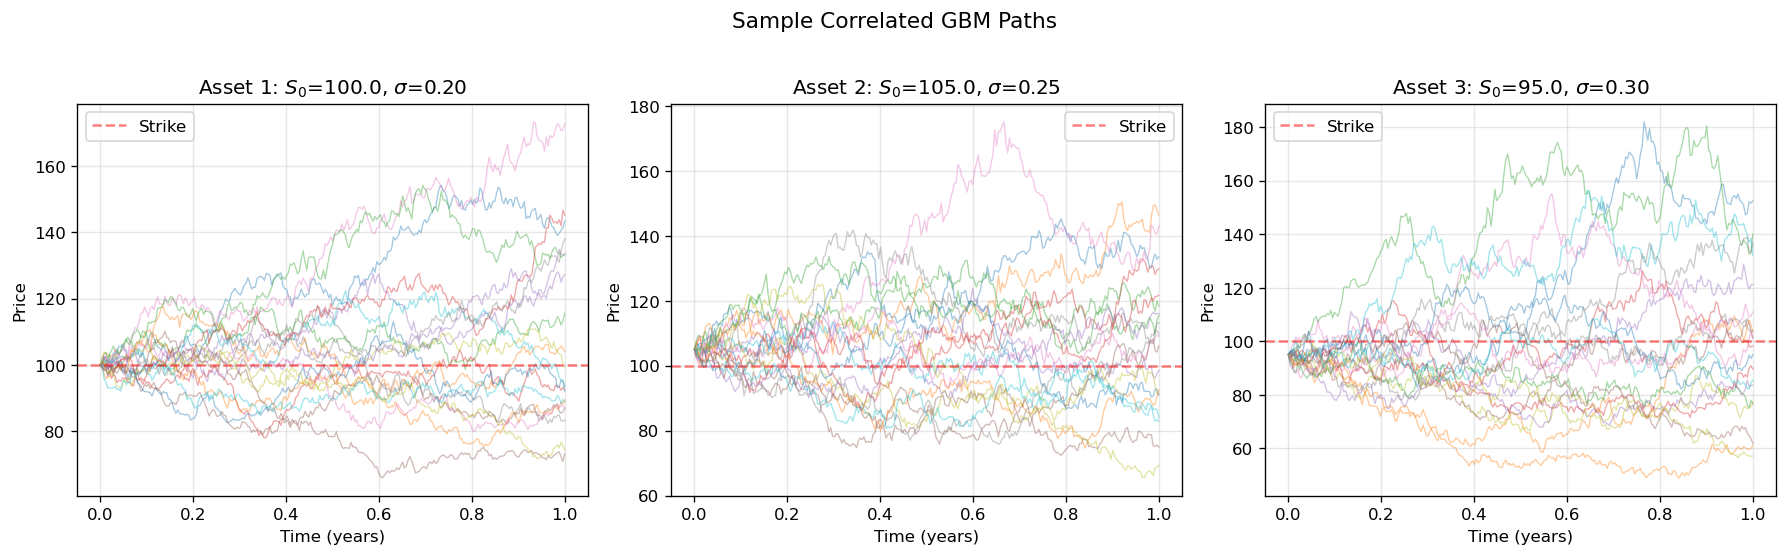

In [5]:
# =============================================================================
# Plot Sample Paths
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

time_grid = np.linspace(0, T, paths.shape[1])
n_plot = 20  # Number of paths to visualize
colors = cm.tab10(np.linspace(0, 1, n_assets))

for asset_idx in range(n_assets):
    ax = axes[asset_idx]
    for p in range(min(n_plot, paths.shape[0])):
        ax.plot(time_grid, paths[p, :, asset_idx], alpha=0.4, linewidth=0.8)
    
    ax.axhline(K, color='red', linestyle='--', alpha=0.5, label='Strike')
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Price')
    ax.set_title(f'Asset {asset_idx + 1}: $S_0$={S0[asset_idx]:.1f}, ' 
                 f'$\\sigma$={sigma[asset_idx]:.2f}')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('Sample Correlated GBM Paths', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 8. Basket Value Distribution at Maturity

The basket value is a weighted sum of correlated lognormals, which is **not** lognormally distributed. We visualize the histogram of $A(T)$ and overlay the payoff function to see where the option has value.


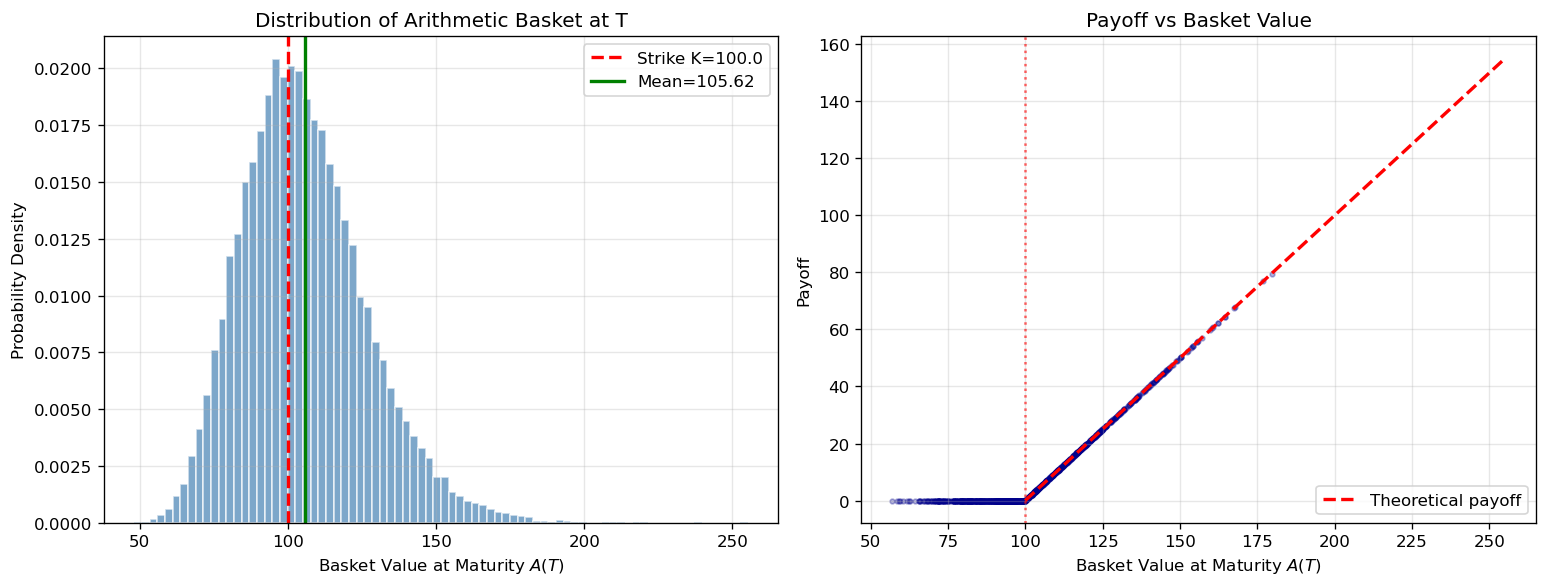

In [6]:
# =============================================================================
# Basket Distribution & Payoff Visualization
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Histogram of basket values at maturity
ax1 = axes[0]
counts, bins, patches = ax1.hist(basket_T, bins=80, density=True, 
                                  color='steelblue', alpha=0.7, edgecolor='white')
ax1.axvline(K, color='red', linestyle='--', linewidth=2, label=f'Strike K={K}')
ax1.axvline(np.mean(basket_T), color='green', linestyle='-', linewidth=2, 
            label=f'Mean={np.mean(basket_T):.2f}')
ax1.set_xlabel('Basket Value at Maturity $A(T)$')
ax1.set_ylabel('Probability Density')
ax1.set_title('Distribution of Arithmetic Basket at T')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Payoff vs basket value scatter
ax2 = axes[1]
ax2.scatter(basket_T[::50], payoffs[::50], alpha=0.3, s=8, color='darkblue')
ax2.plot([K, max(basket_T)], [0, max(basket_T) - K], 'r--', linewidth=2, 
         label='Theoretical payoff')
ax2.axvline(K, color='red', linestyle=':', alpha=0.6)
ax2.set_xlabel('Basket Value at Maturity $A(T)$')
ax2.set_ylabel('Payoff')
ax2.set_title('Payoff vs Basket Value')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Geometric Basket Closed-Form Benchmark

For a geometric basket with weights $w_i$, define:

$$\sigma_G^2 = \sum_{i=1}^{n}\sum_{j=1}^{n} w_i w_j \sigma_i \sigma_j \rho_{ij}$$

$$q_G = \frac{1}{2}\left(\sum_{i=1}^{n} w_i \sigma_i^2 - \sigma_G^2\right)$$

$$S_G(0) = \prod_{i=1}^{n} S_i(0)^{w_i}$$

Then the geometric basket call price is exactly the Black-Scholes formula with spot $S_G(0)$, volatility $\sigma_G$, and dividend yield $q_G$:

$$C_G = S_G(0)\,e^{-q_G T}\,N(d_1) - K\,e^{-rT}\,N(d_2)$$

This serves as a lower bound for the arithmetic basket call (by Jensen's inequality, since geometric mean $\leq$ arithmetic mean).


In [7]:
# =============================================================================
# Geometric Basket Closed-Form & Comparison
# =============================================================================
def geometric_basket_price(S0, sigma, corr, weights, r, T, K, option_type='call'):
    """
    Closed-form price for geometric basket option using Black-Scholes.
    """
    n = len(S0)
    
    # Effective volatility
    cov_matrix = np.outer(sigma, sigma) * corr
    sigma_G_sq = np.sum(weights[:, None] * weights[None, :] * cov_matrix)
    sigma_G = np.sqrt(sigma_G_sq)
    
    # Effective dividend yield
    q_G = 0.5 * (np.sum(weights * sigma**2) - sigma_G_sq)
    
    # Geometric spot
    S_G0 = np.prod(S0**weights)
    
    # Black-Scholes d1, d2
    d1 = (np.log(S_G0 / K) + (r - q_G + 0.5 * sigma_G_sq) * T) / (sigma_G * np.sqrt(T))
    d2 = d1 - sigma_G * np.sqrt(T)
    
    if option_type == 'call':
        price = S_G0 * np.exp(-q_G * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S_G0 * np.exp(-q_G * T) * norm.cdf(-d1)
    
    return price, sigma_G, q_G, S_G0


price_geo, sigma_G, q_G, S_G0 = geometric_basket_price(
    S0, sigma, corr, weights, r, T, K, option_type='call'
)

print("=" * 55)
print("GEOMETRIC BASKET CLOSED-FORM BENCHMARK")
print("=" * 55)
print(f"Geometric spot S_G(0):     {S_G0:.4f}")
print(f"Effective volatility:      {sigma_G:.4f}")
print(f"Effective dividend yield:  {q_G:.4f}")
print(f"Geometric Basket Call:     {price_geo:.4f}")
print("-" * 55)
print(f"Arithmetic MC Call:        {price_mc:.4f}")
print(f"Difference (Arith - Geo):  {price_mc - price_geo:.4f}")
print("=" * 55)
print("Note: Arithmetic >= Geometric (Jensen's inequality), so")
print("      the difference should be positive.")


GEOMETRIC BASKET CLOSED-FORM BENCHMARK
Geometric spot S_G(0):     100.4262
Effective volatility:      0.1956
Effective dividend yield:  0.0111
Geometric Basket Call:     9.8553
-------------------------------------------------------
Arithmetic MC Call:        10.5983
Difference (Arith - Geo):  0.7430
Note: Arithmetic >= Geometric (Jensen's inequality), so
      the difference should be positive.


## 10. Monte Carlo Convergence Analysis

A key diagnostic: as we increase the number of paths $N$, the MC estimate should converge to the true price, and the standard error should shrink as $1/\sqrt{N}$. We verify this empirically.


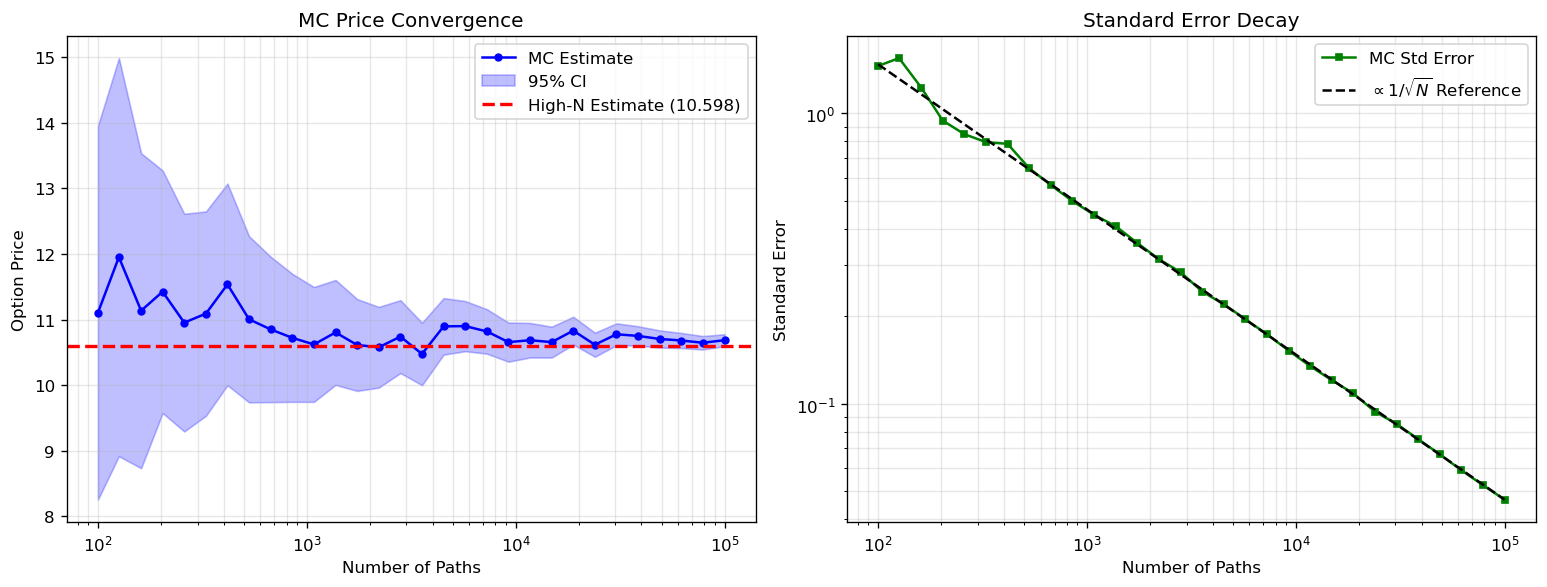

In [8]:
# =============================================================================
# Convergence Analysis
# =============================================================================
path_counts = np.logspace(2, 5, 30, dtype=int)  # 100 to ~100,000
prices_conv = []
errors_conv = []

for N in path_counts:
    p, se, _, _, _ = simulate_basket_mc(
        S0, sigma, corr, weights, r, T, K, 
        n_paths=N, n_steps=252, option_type='call', seed=123
    )
    prices_conv.append(p)
    errors_conv.append(se)

prices_conv = np.array(prices_conv)
errors_conv = np.array(errors_conv)

# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Price convergence
ax1 = axes[0]
ax1.plot(path_counts, prices_conv, 'b-o', markersize=4, linewidth=1.5, 
         label='MC Estimate')
ax1.fill_between(path_counts, 
                 prices_conv - 1.96 * errors_conv,
                 prices_conv + 1.96 * errors_conv,
                 alpha=0.25, color='blue', label='95% CI')
ax1.axhline(price_mc, color='red', linestyle='--', linewidth=2, 
            label=f'High-N Estimate ({price_mc:.3f})')
ax1.set_xscale('log')
ax1.set_xlabel('Number of Paths')
ax1.set_ylabel('Option Price')
ax1.set_title('MC Price Convergence')
ax1.legend()
ax1.grid(True, alpha=0.3, which='both')

# Standard error decay
ax2 = axes[1]
ax2.plot(path_counts, errors_conv, 'g-s', markersize=4, linewidth=1.5, 
         label='MC Std Error')
# Theoretical 1/sqrt(N) decay reference
ref_N = path_counts[-1]
ref_err = errors_conv[-1] * np.sqrt(ref_N / path_counts)
ax2.plot(path_counts, ref_err, 'k--', linewidth=1.5, 
         label=r'$\propto 1/\sqrt{N}$ Reference')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Number of Paths')
ax2.set_ylabel('Standard Error')
ax2.set_title('Standard Error Decay')
ax2.legend()
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()


## 11. Sensitivity to Correlation: The Diversification Effect

Basket options are cheaper when assets are less correlated because diversification reduces basket volatility. We compute the arithmetic basket call price as a function of a uniform correlation parameter $\rho$ (where all off-diagonal entries equal $\rho$).

This creates a **correlation skew** — the price increases monotonically with correlation because high correlation destroys diversification.


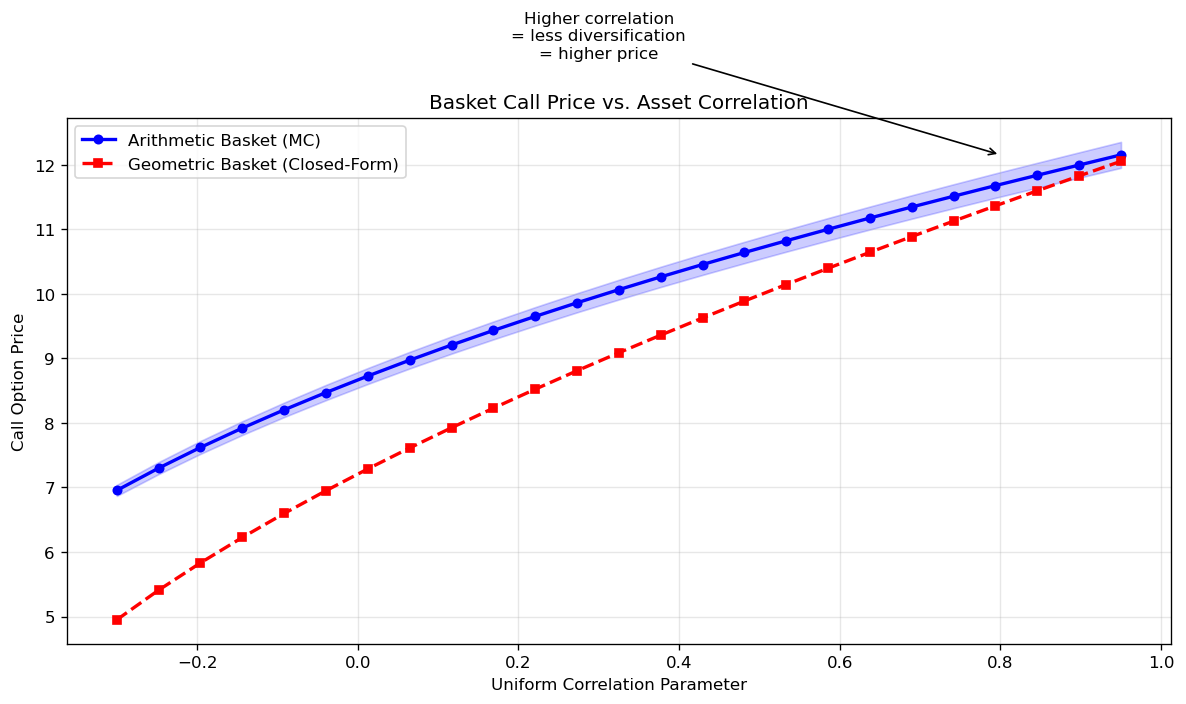

In [9]:
# =============================================================================
# Correlation Sensitivity Analysis
# =============================================================================
rho_values = np.linspace(-0.3, 0.95, 25)
prices_rho = []
errors_rho = []

for rho in rho_values:
    # Build uniform correlation matrix
    corr_rho = np.eye(n_assets)
    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            corr_rho[i, j] = rho
            corr_rho[j, i] = rho
    
    # Check positive semi-definiteness
    min_eig = np.min(np.linalg.eigvalsh(corr_rho))
    if min_eig < -1e-10:
        continue  # Skip invalid correlation matrices
    
    p, se, _, _, _ = simulate_basket_mc(
        S0, sigma, corr_rho, weights, r, T, K,
        n_paths=30000, n_steps=252, option_type='call', seed=456
    )
    prices_rho.append(p)
    errors_rho.append(se)

prices_rho = np.array(prices_rho)
errors_rho = np.array(errors_rho)
valid_rho = rho_values[:len(prices_rho)]

# Also compute geometric prices for comparison
geo_prices_rho = []
for rho in valid_rho:
    corr_rho = np.eye(n_assets)
    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            corr_rho[i, j] = rho
            corr_rho[j, i] = rho
    p_geo, _, _, _ = geometric_basket_price(
        S0, sigma, corr_rho, weights, r, T, K, option_type='call'
    )
    geo_prices_rho.append(p_geo)

geo_prices_rho = np.array(geo_prices_rho)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(valid_rho, prices_rho, 'b-o', markersize=5, linewidth=2, 
        label='Arithmetic Basket (MC)')
ax.fill_between(valid_rho,
                prices_rho - 1.96 * errors_rho,
                prices_rho + 1.96 * errors_rho,
                alpha=0.2, color='blue')
ax.plot(valid_rho, geo_prices_rho, 'r--s', markersize=5, linewidth=2,
        label='Geometric Basket (Closed-Form)')

ax.set_xlabel('Uniform Correlation Parameter')
ax.set_ylabel('Call Option Price')
ax.set_title('Basket Call Price vs. Asset Correlation')
ax.legend()
ax.grid(True, alpha=0.3)

# Annotation
ax.annotate('Higher correlation\n= less diversification\n= higher price',
            xy=(0.8, prices_rho[-1]), xytext=(0.3, prices_rho[-1] + 1.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, ha='center')

plt.tight_layout()
plt.show()


## 12. 2D Heatmap: Price as Function of Strike and Correlation

A more complete view: how does the basket call price vary jointly with strike $K$ and correlation $\rho$? This is useful for traders managing multi-asset books.


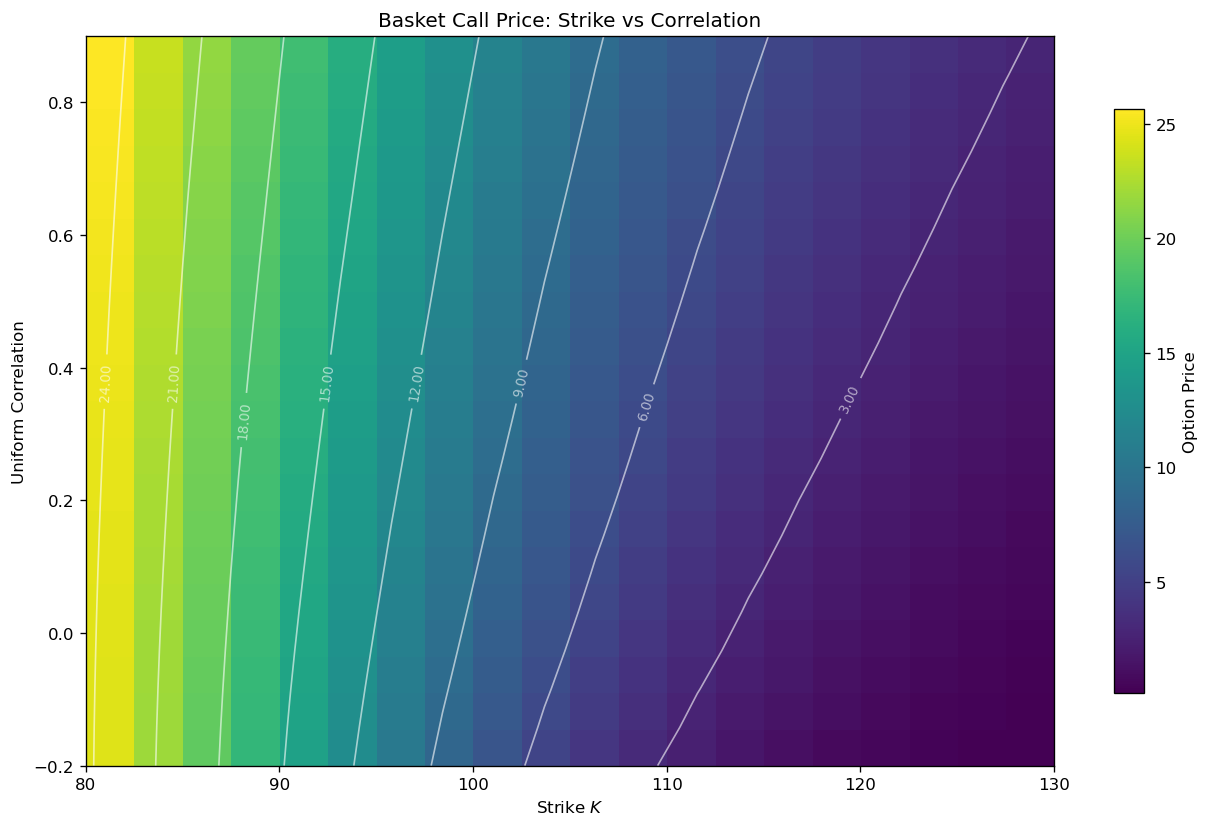

In [10]:
# =============================================================================
# Strike-Correlation Heatmap
# =============================================================================
K_values = np.linspace(80, 130, 20)
rho_values_2d = np.linspace(-0.2, 0.9, 20)

price_grid = np.zeros((len(rho_values_2d), len(K_values)))

for i, rho in enumerate(rho_values_2d):
    corr_rho = np.eye(n_assets)
    for a in range(n_assets):
        for b in range(a + 1, n_assets):
            corr_rho[a, b] = rho
            corr_rho[b, a] = rho
    
    for j, K_val in enumerate(K_values):
        p, _, _, _, _ = simulate_basket_mc(
            S0, sigma, corr_rho, weights, r, T, K_val,
            n_paths=15000, n_steps=100, option_type='call', seed=789
        )
        price_grid[i, j] = p

# Plot heatmap
fig, ax = plt.subplots(figsize=(11, 7))

im = ax.imshow(price_grid, aspect='auto', origin='lower', cmap='viridis',
               extent=[K_values[0], K_values[-1], rho_values_2d[0], rho_values_2d[-1]])

ax.set_xlabel('Strike $K$')
ax.set_ylabel('Uniform Correlation')
ax.set_title('Basket Call Price: Strike vs Correlation')

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Option Price')

# Add contour lines
cs = ax.contour(K_values, rho_values_2d, price_grid, levels=8, colors='white', 
                alpha=0.6, linewidths=1)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.2f')

plt.tight_layout()
plt.show()


## 13. Antithetic Variates Variance Reduction

A simple but effective variance reduction technique: for every path generated with random vector $\mathbf{Z}$, generate a paired path with $-\mathbf{Z}$. This preserves the correlation structure (since $-\mathbf{Z}$ has the same covariance) and can dramatically reduce variance for symmetric payoffs.

We compare standard MC vs antithetic variates on the same number of *actual* random number generations.


In [11]:
# =============================================================================
# Antithetic Variates Implementation
# =============================================================================
def simulate_basket_antithetic(S0, sigma, corr, weights, r, T, K, n_paths, 
                                n_steps=252, option_type='call', seed=None):
    """
    Monte Carlo with antithetic variates. 
    n_paths is the number of PAIRS (so 2*n_paths total paths).
    """
    if seed is not None:
        np.random.seed(seed)
    
    n_assets = len(S0)
    dt = T / n_steps
    L = np.linalg.cholesky(corr)
    drift = (r - 0.5 * sigma**2) * dt
    
    payoffs = []
    
    for _ in range(n_paths):
        # Base path
        S_pos = S0.copy()
        S_neg = S0.copy()
        
        for step in range(n_steps):
            Z = np.random.standard_normal(n_assets)
            dW_pos = Z @ L.T * np.sqrt(dt)
            dW_neg = -Z @ L.T * np.sqrt(dt)
            
            S_pos = S_pos * np.exp(drift + sigma * dW_pos)
            S_neg = S_neg * np.exp(drift + sigma * dW_neg)
        
        basket_pos = np.sum(S_pos * weights)
        basket_neg = np.sum(S_neg * weights)
        
        if option_type == 'call':
            payoffs.append(np.maximum(basket_pos - K, 0.0))
            payoffs.append(np.maximum(basket_neg - K, 0.0))
        else:
            payoffs.append(np.maximum(K - basket_pos, 0.0))
            payoffs.append(np.maximum(K - basket_neg, 0.0))
    
    payoffs = np.array(payoffs)
    discount = np.exp(-r * T)
    price = discount * np.mean(payoffs)
    std_err = discount * np.std(payoffs, ddof=1) / np.sqrt(len(payoffs))
    
    return price, std_err, payoffs


# Compare standard vs antithetic
N_test = 25000

p_std, se_std, _, _, _ = simulate_basket_mc(
    S0, sigma, corr, weights, r, T, K, n_paths=N_test, seed=111
)

p_anti, se_anti, _ = simulate_basket_antithetic(
    S0, sigma, corr, weights, r, T, K, n_paths=N_test, seed=111
)

variance_ratio = (se_std / se_anti)**2

print("=" * 55)
print("VARIANCE REDUCTION: ANTITHETIC VARIATES")
print("=" * 55)
print(f"Standard MC:      Price={p_std:.4f}, SE={se_std:.6f}")
print(f"Antithetic MC:    Price={p_anti:.4f}, SE={se_anti:.6f}")
print(f"Variance Ratio:   {variance_ratio:.2f}x")
print(f"Effective paths:  {2*N_test:,} (antithetic)")
print("=" * 55)


VARIANCE REDUCTION: ANTITHETIC VARIATES
Standard MC:      Price=10.5662, SE=0.092523
Antithetic MC:    Price=10.6034, SE=0.065293
Variance Ratio:   2.01x
Effective paths:  50,000 (antithetic)


## 14. Summary & Key Takeaways

| Concept | Insight |
|---------|---------|
| **Basket Option** | Payoff on weighted average of $n$ assets; cheaper than $n$ individual options due to diversification. |
| **Correlation** | Higher correlation $\Rightarrow$ higher basket volatility $\Rightarrow$ higher option price. |
| **Cholesky** | The standard method to generate correlated Brownian increments from independent normals. |
| **Arithmetic vs Geometric** | Arithmetic basket has no closed form; geometric basket provides a useful lower bound. |
| **MC Convergence** | Error decays as $1/\sqrt{N}$; variance reduction (antithetic, control variates, quasi-MC) is essential for production. |
| **Diversification Value** | The price difference between high and low correlation regimes quantifies the economic value of diversification. |

### Practical Notes
- For $n > 3$ assets, ensure the correlation matrix is positive semi-definite (check eigenvalues).
- For American-style basket options, use **Least-Squares Monte Carlo** (Longstaff-Schwarz).
- For large $n$, consider **quasi-Monte Carlo** (Sobol sequences) for faster convergence.